# Connect-4 Transformer Model (Google Colab Version)

**Instructions:**
1. Go to Runtime → Change runtime type → Select **GPU** (T4 is fine)
2. Upload your `mcts_not_mirrored_2000.npz` file when prompted
3. Run all cells
4. Download the trained `transformer.weights.h5` file at the end
---

In [1]:
# Check GPU and TensorFlow version
import tensorflow as tf
print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {len(tf.config.list_physical_devices('GPU')) > 0}")
if tf.config.list_physical_devices('GPU'):
    print(f"GPU device: {tf.config.list_physical_devices('GPU')[0]}")

TensorFlow version: 2.19.0
GPU available: True
GPU device: PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')


In [2]:
# Upload your data file
from google.colab import files
import os

print("Please upload 'mcts_not_mirrored_2000.npz' file:")
uploaded = files.upload()

data_filename = list(uploaded.keys())[0]
print(f"\nUploaded: {data_filename}")

Please upload 'mcts_not_mirrored_2000.npz' file:


Saving mcts_not_mirrored_2000.npz to mcts_not_mirrored_2000.npz

Uploaded: mcts_not_mirrored_2000.npz


In [3]:
import numpy as np
from sklearn.model_selection import train_test_split

# Load data
data = np.load(data_filename)
print(f"Available arrays: {list(data.keys())}")

X = data['X']  # Shape: (N, 6, 7, 2)
policy = data['policy']  # Shape: (N, 7)
value = data['value']  # Shape: (N, 1)

print(f"\nLoaded {X.shape[0]:,} samples")
print(f"X shape: {X.shape}")
print(f"Policy shape: {policy.shape}")
print(f"Value shape: {value.shape}")

Available arrays: ['boards', 'visits', 'scores', 'policy', 'q', 'value', 'X']

Loaded 703,111 samples
X shape: (703111, 6, 7, 2)
Policy shape: (703111, 7)
Value shape: (703111, 1)


## Data Preparation

In [4]:
# Reshape for transformer: (N, 6, 7, 2) -> (N, 42, 2)
N = X.shape[0]
X_flat = X.reshape(N, 42, 2).astype(np.float32)
print(f"Transformer input shape: {X_flat.shape}")

Transformer input shape: (703111, 42, 2)


In [5]:
# Mirror data for augmentation (doubles dataset)
def mirror_data(X_flat, policy, value):
    """Apply horizontal mirroring to double the dataset."""
    N = X_flat.shape[0]

    # Reshape to (N, 6, 7, 2), flip columns, reshape back
    X_reshaped = X_flat.reshape(N, 6, 7, 2)
    X_mirrored = X_reshaped[:, :, ::-1, :].reshape(N, 42, 2)

    # Mirror policy (reverse columns)
    policy_mirrored = policy[:, ::-1]

    # Concatenate
    return (
        np.concatenate([X_flat, X_mirrored], axis=0),
        np.concatenate([policy, policy_mirrored], axis=0),
        np.concatenate([value, value], axis=0)
    )

X_aug, policy_aug, value_aug = mirror_data(X_flat, policy, value)
print(f"After mirroring: {X_aug.shape[0]:,} samples")

After mirroring: 1,406,222 samples


In [6]:
# Split into train/validation
X_train, X_val, policy_train, policy_val, value_train, value_val = train_test_split(
    X_aug, policy_aug, value_aug,
    test_size=0.1,
    random_state=42,
    shuffle=True
)

print(f"Training: {X_train.shape[0]:,} samples")
print(f"Validation: {X_val.shape[0]:,} samples")

Training: 1,265,599 samples
Validation: 140,623 samples


## Custom Keras Layers

Compatible with TensorFlow 2.x / Keras 2.x

In [7]:
from tensorflow.keras import layers, Model

class PositionalEmbedding(layers.Layer):
    """Adds learned positional embeddings to input patches."""

    def __init__(self, num_patches, hidden_dim, **kwargs):
        super().__init__(**kwargs)
        self.num_patches = num_patches
        self.hidden_dim = hidden_dim

    def build(self, input_shape):
        self.embedding = self.add_weight(
            shape=(1, self.num_patches, self.hidden_dim),
            initializer='random_normal',
            trainable=True,
            name='pos_embedding'
        )
        super().build(input_shape)

    def call(self, x):
        # x shape: (batch, num_patches, features)
        # Just broadcast add the positional embedding
        return self.embedding

    def get_config(self):
        config = super().get_config()
        config.update({
            'num_patches': self.num_patches,
            'hidden_dim': self.hidden_dim
        })
        return config


class ClassToken(layers.Layer):
    """Prepends a learnable class token to the sequence."""

    def __init__(self, hidden_dim, **kwargs):
        super().__init__(**kwargs)
        self.hidden_dim = hidden_dim

    def build(self, input_shape):
        self.class_token = self.add_weight(
            shape=(1, 1, self.hidden_dim),
            initializer='random_normal',
            trainable=True,
            name='class_token'
        )
        super().build(input_shape)

    def call(self, x):
        batch_size = tf.shape(x)[0]
        class_token = tf.broadcast_to(self.class_token, [batch_size, 1, self.hidden_dim])
        return tf.concat([class_token, x], axis=1)

    def get_config(self):
        config = super().get_config()
        config.update({'hidden_dim': self.hidden_dim})
        return config


class TransformerBlock(layers.Layer):
    """A single transformer encoder block with pre-norm."""

    def __init__(self, hidden_dim, num_heads, mlp_dim, dropout_rate=0.1, **kwargs):
        super().__init__(**kwargs)
        self.hidden_dim = hidden_dim
        self.num_heads = num_heads
        self.mlp_dim = mlp_dim
        self.dropout_rate = dropout_rate

    def build(self, input_shape):
        self.ln1 = layers.LayerNormalization(epsilon=1e-6)
        self.mha = layers.MultiHeadAttention(
            num_heads=self.num_heads,
            key_dim=self.hidden_dim // self.num_heads,
            dropout=self.dropout_rate
        )
        self.ln2 = layers.LayerNormalization(epsilon=1e-6)
        self.mlp_dense1 = layers.Dense(self.mlp_dim, activation='gelu')
        self.mlp_dropout1 = layers.Dropout(self.dropout_rate)
        self.mlp_dense2 = layers.Dense(self.hidden_dim)
        self.mlp_dropout2 = layers.Dropout(self.dropout_rate)
        super().build(input_shape)

    def call(self, x, training=None):
        # Pre-norm + Multi-head attention + residual
        ln1_out = self.ln1(x)
        attn_out = self.mha(ln1_out, ln1_out, training=training)
        x = x + attn_out

        # Pre-norm + MLP + residual
        ln2_out = self.ln2(x)
        mlp_out = self.mlp_dense1(ln2_out)
        mlp_out = self.mlp_dropout1(mlp_out, training=training)
        mlp_out = self.mlp_dense2(mlp_out)
        mlp_out = self.mlp_dropout2(mlp_out, training=training)
        return x + mlp_out

    def get_config(self):
        config = super().get_config()
        config.update({
            'hidden_dim': self.hidden_dim,
            'num_heads': self.num_heads,
            'mlp_dim': self.mlp_dim,
            'dropout_rate': self.dropout_rate
        })
        return config

print("Custom layers defined!")

Custom layers defined!


## Build Transformer Model

In [29]:
def build_connect4_transformer(
    num_rows=6,
    num_cols=7,
    patch_features=2,
    hidden_dim=128,
    num_layers=6,
    num_heads=8,
    mlp_dim=256,
    dropout_rate=0.1,
):
    """
    Build a Vision Transformer for Connect-4 with policy and value heads.
    """
    num_patches = num_rows * num_cols  # 42

    # Input: (batch, 42, 2)
    inp = layers.Input(shape=(num_patches, patch_features), name='board_input')

    # Project patches to hidden dimension
    x = layers.Dense(hidden_dim, name='patch_projection')(inp)

    # Add positional embeddings
    pos_emb = PositionalEmbedding(num_patches, hidden_dim, name='pos_embedding')(inp)
    x = layers.Add()([x, pos_emb])
    x = layers.Dropout(dropout_rate)(x)

    # Add class token
    x = ClassToken(hidden_dim, name='class_token_layer')(x)  # (batch, 43, hidden_dim)

    # Transformer encoder blocks
    for i in range(num_layers):
        x = TransformerBlock(
            hidden_dim=hidden_dim,
            num_heads=num_heads,
            mlp_dim=mlp_dim,
            dropout_rate=dropout_rate,
            name=f'transformer_block_{i}'
        )(x)

    # Final layer norm
    x = layers.LayerNormalization(epsilon=1e-6, name='final_ln')(x)

    # ============ POLICY HEAD ============
    # Extract patch tokens (skip class token at index 0)
    patch_tokens = layers.Lambda(lambda t: t[:, 1:, :], name='extract_patches')(x)  # (batch, 42, hidden_dim)

    # Reshape to (batch, 6, 7, hidden_dim) and pool by column
    patch_tokens = layers.Reshape((num_rows, num_cols, hidden_dim), name='reshape_patches')(patch_tokens)
    col_features = layers.Lambda(lambda t: tf.reduce_mean(t, axis=1), name='col_pooling')(patch_tokens)  # (batch, 7, hidden_dim)

    # MLP for policy
    policy_hidden = layers.Dense(64, activation='relu', name='policy_dense1')(col_features)
    policy_logits = layers.Dense(1, name='policy_dense2')(policy_hidden)  # (batch, 7, 1)
    policy_logits = layers.Flatten(name='policy_flatten')(policy_logits)  # (batch, 7)
    policy_output = layers.Softmax(name='policy')(policy_logits)

    # ============ VALUE HEAD ============
    # Extract class token (index 0)
    class_token_out = layers.Lambda(lambda t: t[:, 0, :], name='extract_class')(x)  # (batch, hidden_dim)

    # MLP for value
    value_hidden = layers.Dense(128, activation='relu', name='value_dense1')(class_token_out)
    value_hidden = layers.Dropout(dropout_rate)(value_hidden)
    value_hidden = layers.Dense(64, activation='relu', name='value_dense2')(value_hidden)
    value_output = layers.Dense(1, activation='tanh', name='value')(value_hidden)

    model = Model(
        inputs=inp,
        outputs=[policy_output, value_output],
        name='Connect4_Transformer'
    )
    return model

In [30]:
# Build model with competitive hyperparameters
model = build_connect4_transformer(
    hidden_dim=128,     # Transformer dimension
    num_layers=6,       # 6 transformer blocks
    num_heads=8,        # 8 attention heads
    mlp_dim=256,        # MLP expansion
    dropout_rate=0.1,
)

model.summary()

Model: "Connect4_Transformer"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ board_input         │ (None, 42, 2)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patch_projection    │ (None, 42, 128)   │        384 │ board_input[0][0] │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pos_embedding       │ (1, 42, 128)      │      5,376 │ board_input[0][0] │
│ (PositionalEmbeddi… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (1, 42, 128)      │          0 │ patch_projection… │
│                     │                   │            │ pos_embedding[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_78          │ (1, 42, 128)      │          0 │ add_3[0][0]       │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ class_token_layer   │ (1, 43, 128)      │        128 │ dropout_78[0][0]  │
│ (ClassToken)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_block_0 │ (1, 43, 128)      │    132,480 │ class_token_laye… │
│ (TransformerBlock)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_block_1 │ (1, 43, 128)      │    132,480 │ transformer_bloc… │
│ (TransformerBlock)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_block_2 │ (1, 43, 128)      │    132,480 │ transformer_bloc… │
│ (TransformerBlock)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_block_3 │ (1, 43, 128)      │    132,480 │ transformer_bloc… │
│ (TransformerBlock)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_block_4 │ (1, 43, 128)      │    132,480 │ transformer_bloc… │
│ (TransformerBlock)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_block_5 │ (1, 43, 128)      │    132,480 │ transformer_bloc… │
│ (TransformerBlock)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ final_ln            │ (1, 43, 128)      │        256 │ transformer_bloc… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ extract_patches     │ (1, 42, 128)      │          0 │ final_ln[0][0]    │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_patches     │ (1, 6, 7, 128)    │          0 │ extract_patches[… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ col_pooling         │ (1, 7, 128)       │          0 │ reshape_patches[… │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ extract_class       │ (1, 128)          │          0 │ final_ln[0][0]  

 Total params: 834,178 (3.18 MB)

 Trainable params: 834,178 (3.18 MB)

 Non-trainable params: 0 (0.00 B)

In [31]:
# Compile with AdamW optimizer
model.compile(
    optimizer=tf.keras.optimizers.AdamW(
        learning_rate=1e-3,
        weight_decay=1e-4,
    ),
    loss={
        'policy': 'categorical_crossentropy',
        'value': 'mse'
    },
    loss_weights={'policy': 1.0, 'value': 1.0},
    metrics={
        'policy': ['accuracy', tf.keras.metrics.TopKCategoricalAccuracy(k=2, name='top2_acc')],
        'value': 'mae'
    }
)

print("Model compiled!")

Model compiled!


## Training

In [11]:
# Callbacks
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_policy_accuracy',
        patience=10,
        mode='max',
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    ),
]

In [12]:
# Train!
history = model.fit(
    X_train,
    {'policy': policy_train, 'value': value_train},
    validation_data=(X_val, {'policy': policy_val, 'value': value_val}),
    epochs=50,
    batch_size=512,  # Larger batch for transformers
    callbacks=callbacks,
    verbose=1
)

Epoch 1/50
2472/2472 ━━━━━━━━━━━━━━━━━━━━ 345s 124ms/step - loss: 1.8929 - policy_accuracy: 0.4339 - policy_loss: 1.7098 - policy_top2_acc: 0.6504 - value_loss: 0.1830 - value_mae: 0.3192 - val_loss: 1.6841 - val_policy_accuracy: 0.5737 - val_policy_loss: 1.5697 - val_policy_top2_acc: 0.7802 - val_value_loss: 0.1144 - val_value_mae: 0.2279 - learning_rate: 0.0010
Epoch 2/50
2472/2472 ━━━━━━━━━━━━━━━━━━━━ 282s 114ms/step - loss: 1.6887 - policy_accuracy: 0.5671 - policy_loss: 1.5733 - policy_top2_acc: 0.7775 - value_loss: 0.1155 - value_mae: 0.2331 - val_loss: 1.6249 - val_policy_accuracy: 0.6043 - val_policy_loss: 1.5391 - val_policy_top2_acc: 0.8064 - val_value_loss: 0.0859 - val_value_mae: 0.1863 - learning_rate: 0.0010
Epoch 3/50
2472/2472 ━━━━━━━━━━━━━━━━━━━━ 281s 114ms/step - loss: 1.6372 - policy_accuracy: 0.6018 - policy_loss: 1.5428 - policy_top2_acc: 0.8065 - value_loss: 0.0943 - value_mae: 0.2023 - val_loss: 1.5647 - val_policy_accuracy: 0.6564 - val_policy_loss: 1.4949 - val

In [24]:
 # Save the trained weights
model.save_weights('transformer.weights.h5')
print("Weights saved!")

# Download
from google.colab import files
files.download('transformer.weights.h5')

Weights saved!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [26]:
# Rebuild the model and load weights
model2 = build_connect4_transformer(
    hidden_dim=128,
    num_layers=6,
    num_heads=8,
    mlp_dim=256,
    dropout_rate=0.1,
)
model2.load_weights('transformer.weights.h5')
print("Weights loaded successfully!")

# Test prediction
test_board = np.zeros((1, 42, 2), dtype=np.float32)
policy_out, value_out = model2.predict(test_board, verbose=0)
print(f"\nEmpty board prediction:")
print(f"  Policy: {np.round(policy_out[0], 3)}")
print(f"  Value: {value_out[0,0]:.3f}")
print(f"  Best column: {np.argmax(policy_out[0])}")

Weights loaded successfully!

Empty board prediction:
  Policy: [0.085 0.101 0.171 0.297 0.162 0.099 0.084]
  Value: 0.151
  Best column: 3


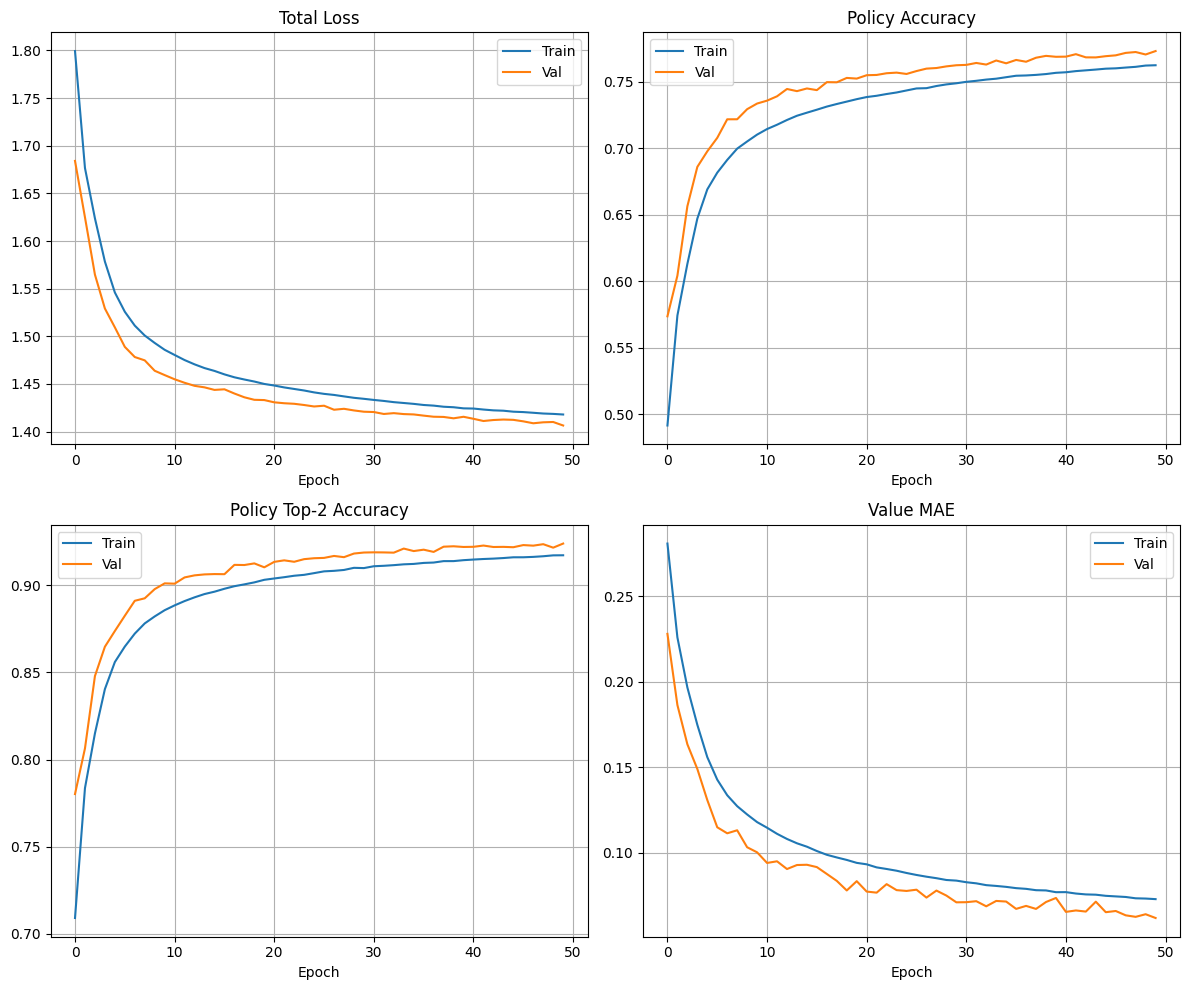

In [13]:
# Plot training history
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Loss
axes[0, 0].plot(history.history['loss'], label='Train')
axes[0, 0].plot(history.history['val_loss'], label='Val')
axes[0, 0].set_title('Total Loss')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].legend()
axes[0, 0].grid(True)

# Policy accuracy
axes[0, 1].plot(history.history['policy_accuracy'], label='Train')
axes[0, 1].plot(history.history['val_policy_accuracy'], label='Val')
axes[0, 1].set_title('Policy Accuracy')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].legend()
axes[0, 1].grid(True)

# Top-2 accuracy
axes[1, 0].plot(history.history['policy_top2_acc'], label='Train')
axes[1, 0].plot(history.history['val_policy_top2_acc'], label='Val')
axes[1, 0].set_title('Policy Top-2 Accuracy')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].legend()
axes[1, 0].grid(True)

# Value MAE
axes[1, 1].plot(history.history['value_mae'], label='Train')
axes[1, 1].plot(history.history['val_value_mae'], label='Val')
axes[1, 1].set_title('Value MAE')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].legend()
axes[1, 1].grid(True)

plt.tight_layout()
plt.savefig('training_history.png', dpi=150)
plt.show()

## Evaluation

In [14]:
# Final evaluation
results = model.evaluate(
    X_val,
    {'policy': policy_val, 'value': value_val},
    verbose=0
)

print("\n" + "="*50)
print("FINAL VALIDATION RESULTS")
print("="*50)
print(f"Total Loss:        {results[0]:.4f}")
print(f"Policy Loss:       {results[1]:.4f}")
print(f"Value Loss:        {results[2]:.4f}")
print(f"Policy Accuracy:   {results[3]*100:.2f}%")
print(f"Policy Top-2 Acc:  {results[4]*100:.2f}%")
print(f"Value MAE:         {results[5]:.4f}")
print("="*50)


FINAL VALIDATION RESULTS
Total Loss:        1.4064
Policy Loss:       1.3956
Value Loss:        0.0108
Policy Accuracy:   77.29%
Policy Top-2 Acc:  92.39%
Value MAE:         0.0617


In [15]:
# Show some predictions
np.random.seed(42)
sample_idx = np.random.choice(len(X_val), 5, replace=False)

for idx in sample_idx:
    board = X_val[idx:idx+1]
    true_policy = policy_val[idx]
    true_value = value_val[idx, 0]

    pred_policy, pred_value = model.predict(board, verbose=0)

    print(f"\n--- Sample {idx} ---")
    print(f"True policy: {np.round(true_policy, 2)}")
    print(f"Pred policy: {np.round(pred_policy[0], 2)}")
    print(f"True move: Col {np.argmax(true_policy)} | Pred move: Col {np.argmax(pred_policy[0])}")
    print(f"True value: {true_value:.3f} | Pred value: {pred_value[0,0]:.3f}")


--- Sample 41865 ---
True policy: [0.04 0.03 0.05 0.59 0.09 0.09 0.1 ]
Pred policy: [0.07 0.05 0.04 0.58 0.13 0.08 0.04]
True move: Col 3 | Pred move: Col 3
True value: 0.022 | Pred value: -0.022

--- Sample 45735 ---
True policy: [0.11 0.06 0.26 0.07 0.31 0.09 0.09]
Pred policy: [0.09 0.04 0.25 0.06 0.41 0.07 0.08]
True move: Col 4 | Pred move: Col 4
True value: 0.061 | Pred value: 0.067

--- Sample 24573 ---
True policy: [0.03 0.8  0.02 0.07 0.02 0.03 0.02]
Pred policy: [0.03 0.82 0.03 0.04 0.01 0.04 0.04]
True move: Col 1 | Pred move: Col 1
True value: -0.012 | Pred value: 0.014

--- Sample 80529 ---
True policy: [0.05 0.13 0.06 0.2  0.21 0.22 0.13]
Pred policy: [0.06 0.12 0.08 0.23 0.21 0.19 0.1 ]
True move: Col 5 | Pred move: Col 3
True value: -0.170 | Pred value: -0.135

--- Sample 23040 ---
True policy: [0.05 0.34 0.06 0.05 0.13 0.17 0.2 ]
Pred policy: [0.11 0.32 0.08 0.09 0.08 0.14 0.18]
True move: Col 1 | Pred move: Col 1
True value: -0.113 | Pred value: -0.097


## Save Model

In [27]:
# Save weights (works reliably)
model.save_weights('transformer.weights.h5')
print("Weights saved!")

# Download weights
from google.colab import files
files.download('transformer.weights.h5')
files.download('training_history.png')

Weights saved!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Test Model Loading

In [28]:
# Rebuild model and load weights
model2 = build_connect4_transformer(
    hidden_dim=128,
    num_layers=6,
    num_heads=8,
    mlp_dim=256,
    dropout_rate=0.1,
)
model2.load_weights('transformer.weights.h5')
print("Model loaded successfully!")

# Test
test_board = np.zeros((1, 42, 2), dtype=np.float32)
policy_out, value_out = model2.predict(test_board, verbose=0)
print(f"\nEmpty board prediction:")
print(f"  Policy: {np.round(policy_out[0], 3)}")
print(f"  Value: {value_out[0,0]:.3f}")
print(f"  Best column: {np.argmax(policy_out[0])}")

Model loaded successfully!

Empty board prediction:
  Policy: [0.085 0.101 0.171 0.297 0.162 0.099 0.084]
  Value: 0.151
  Best column: 3


## AWS Backend Code

Copy this entire code block to your AWS backend `.py` file:

In [ ]:

aws_backend_code = '''
# ============================================
# AWS BACKEND CODE FOR TRANSFORMER
# ============================================
# Copy this to your AWS backend .py file

import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, Model

# ---- Custom Layers (required for building model) ----

class PositionalEmbedding(layers.Layer):
    def __init__(self, num_patches, hidden_dim, **kwargs):
        super().__init__(**kwargs)
        self.num_patches = num_patches
        self.hidden_dim = hidden_dim

    def build(self, input_shape):
        self.embedding = self.add_weight(
            shape=(1, self.num_patches, self.hidden_dim),
            initializer="random_normal",
            trainable=True,
            name="pos_embedding"
        )
        super().build(input_shape)

    def call(self, x):
        return self.embedding

    def get_config(self):
        config = super().get_config()
        config.update({"num_patches": self.num_patches, "hidden_dim": self.hidden_dim})
        return config


class ClassToken(layers.Layer):
    def __init__(self, hidden_dim, **kwargs):
        super().__init__(**kwargs)
        self.hidden_dim = hidden_dim

    def build(self, input_shape):
        self.class_token = self.add_weight(
            shape=(1, 1, self.hidden_dim),
            initializer="random_normal",
            trainable=True,
            name="class_token"
        )
        super().build(input_shape)

    def call(self, x):
        batch_size = tf.shape(x)[0]
        class_token = tf.broadcast_to(self.class_token, [batch_size, 1, self.hidden_dim])
        return tf.concat([class_token, x], axis=1)

    def get_config(self):
        config = super().get_config()
        config.update({"hidden_dim": self.hidden_dim})
        return config


class TransformerBlock(layers.Layer):
    def __init__(self, hidden_dim, num_heads, mlp_dim, dropout_rate=0.1, **kwargs):
        super().__init__(**kwargs)
        self.hidden_dim = hidden_dim
        self.num_heads = num_heads
        self.mlp_dim = mlp_dim
        self.dropout_rate = dropout_rate

    def build(self, input_shape):
        self.ln1 = layers.LayerNormalization(epsilon=1e-6)
        self.mha = layers.MultiHeadAttention(
            num_heads=self.num_heads,
            key_dim=self.hidden_dim // self.num_heads,
            dropout=self.dropout_rate
        )
        self.ln2 = layers.LayerNormalization(epsilon=1e-6)
        self.mlp_dense1 = layers.Dense(self.mlp_dim, activation="gelu")
        self.mlp_dropout1 = layers.Dropout(self.dropout_rate)
        self.mlp_dense2 = layers.Dense(self.hidden_dim)
        self.mlp_dropout2 = layers.Dropout(self.dropout_rate)
        super().build(input_shape)

    def call(self, x, training=None):
        ln1_out = self.ln1(x)
        attn_out = self.mha(ln1_out, ln1_out, training=training)
        x = x + attn_out
        ln2_out = self.ln2(x)
        mlp_out = self.mlp_dense1(ln2_out)
        mlp_out = self.mlp_dropout1(mlp_out, training=training)
        mlp_out = self.mlp_dense2(mlp_out)
        mlp_out = self.mlp_dropout2(mlp_out, training=training)
        return x + mlp_out

    def get_config(self):
        config = super().get_config()
        config.update({
            "hidden_dim": self.hidden_dim,
            "num_heads": self.num_heads,
            "mlp_dim": self.mlp_dim,
            "dropout_rate": self.dropout_rate
        })
        return config


# ---- Build Model Function ----

def build_connect4_transformer(
    num_rows=6, num_cols=7, patch_features=2,
    hidden_dim=128, num_layers=6, num_heads=8,
    mlp_dim=256, dropout_rate=0.1
):
    num_patches = num_rows * num_cols  # 42

    inp = layers.Input(shape=(num_patches, patch_features), name="board_input")
    x = layers.Dense(hidden_dim, name="patch_projection")(inp)

    pos_emb = PositionalEmbedding(num_patches, hidden_dim, name="pos_embedding")(inp)
    x = layers.Add()([x, pos_emb])
    x = layers.Dropout(dropout_rate)(x)
    x = ClassToken(hidden_dim, name="class_token_layer")(x)

    for i in range(num_layers):
        x = TransformerBlock(hidden_dim, num_heads, mlp_dim, dropout_rate,
name=f"transformer_block_{i}")(x)

    x = layers.LayerNormalization(epsilon=1e-6, name="final_ln")(x)

    # Policy head
    patch_tokens = layers.Lambda(lambda t: t[:, 1:, :], name="extract_patches")(x)
    patch_tokens = layers.Reshape((num_rows, num_cols, hidden_dim),
name="reshape_patches")(patch_tokens)
    col_features = layers.Lambda(lambda t: tf.reduce_mean(t, axis=1), name="col_pooling")(patch_tokens)
    policy_hidden = layers.Dense(64, activation="relu", name="policy_dense1")(col_features)
    policy_logits = layers.Dense(1, name="policy_dense2")(policy_hidden)
    policy_logits = layers.Flatten(name="policy_flatten")(policy_logits)
    policy_output = layers.Softmax(name="policy")(policy_logits)

    # Value head
    class_token_out = layers.Lambda(lambda t: t[:, 0, :], name="extract_class")(x)
    value_hidden = layers.Dense(128, activation="relu", name="value_dense1")(class_token_out)
    value_hidden = layers.Dropout(dropout_rate)(value_hidden)
    value_hidden = layers.Dense(64, activation="relu", name="value_dense2")(value_hidden)
    value_output = layers.Dense(1, activation="tanh", name="value")(value_hidden)

    return Model(inputs=inp, outputs=[policy_output, value_output], name="Connect4_Transformer")


# ---- Load Model ----

transformer_model = build_connect4_transformer(
    hidden_dim=128,
    num_layers=6,
    num_heads=8,
    mlp_dim=256,
    dropout_rate=0.1,
)
transformer_model.load_weights("transformer.weights.h5")
print("Transformer model loaded!")


# ---- Prediction Function ----

def transformer_predict_move(board_6x7x2):
    """
    Predict best move using the transformer.

    Args:
        board_6x7x2: numpy array shape (6, 7, 2)
                      channel 0 = current player stones (1 where player has stone)
                      channel 1 = opponent stones (1 where opponent has stone)

    Returns:
        best_column: int 0-6 (the column to play)
    """
    board_flat = board_6x7x2.reshape(1, 42, 2).astype(np.float32)
    policy, value = transformer_model.predict(board_flat, verbose=0)
    return int(np.argmax(policy[0]))
'''

print(aws_backend_code)